In [1]:
import os
import pandas as pd
import numpy as np

In [2]:
X_train = pd.read_csv(
    "UCI HAR Dataset/train/X_train.txt",
    delim_whitespace=True,
    header=None
)

y_train = pd.read_csv(
    "UCI HAR Dataset/train/y_train.txt",
    header=None,
    names=["Activity"]
)


C:\Users\suden\AppData\Local\Temp\ipykernel_14924\2427999988.py:1: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  X_train = pd.read_csv(


In [3]:
X_train.shape, y_train.shape # test


((7352, 561), (7352, 1))

In [4]:
X_train.head()


,0,1,2,3,4,5,6,7,8,9,...,551,552,553,554,555,556,557,558,559,560
0,0.288585,-0.020294,-0.132905,-0.995279,-0.983111,-0.913526,-0.995112,-0.983185,-0.923527,-0.934724,...,-0.074323,-0.298676,-0.710304,-0.112754,0.030400,-0.464761,-0.018446,-0.841247,0.179941,-0.058627
1,0.278419,-0.016411,-0.123520,-0.998245,-0.975300,-0.960322,-0.998807,-0.974914,-0.957686,-0.943068,...,0.158075,-0.595051,-0.861499,0.053477,-0.007435,-0.732626,0.703511,-0.844788,0.180289,-0.054317
2,0.279653,-0.019467,-0.113462,-0.995380,-0.967187,-0.978944,-0.996520,-0.963668,-0.977469,-0.938692,...,0.414503,-0.390748,-0.760104,-0.118559,0.177899,0.100699,0.808529,-0.848933,0.180637,-0.049118
3,0.279174,-0.026201,-0.123283,-0.996091,-0.983403,-0.990675,-0.997099,-0.982750,-0.989302,-0.938692,...,0.404573,-0.117290,-0.482845,-0.036788,-0.012892,0.640011,-0.485366,-0.848649,0.181935,-0.047663
4,0.276629,-0.016570,-0.115362,-0.998139,-0.980817,-0.990482,-0.998321,-0.979672,-0.990441,-0.942469,...,0.087753,-0.351471,-0.699205,0.123320,0.122542,0.693578,-0.615971,-0.847865,0.185151,-0.043892


In [5]:
y_train["Activity"].value_counts()


Activity
6    1407
5    1374
4    1286
1    1226
2    1073
3     986
Name: count, dtype: int64

In [6]:
activity_labels = {
    1: "Walking",
    2: "Walking Upstairs",
    3: "Walking Downstairs",
    4: "Sitting",
    5: "Standing",
    6: "Laying"
}

y_train["ActivityName"] = y_train["Activity"].map(activity_labels)


In [7]:
y_train.head()


,Activity,ActivityName
0,5,Standing
1,5,Standing
2,5,Standing
3,5,Standing
4,5,Standing


In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")


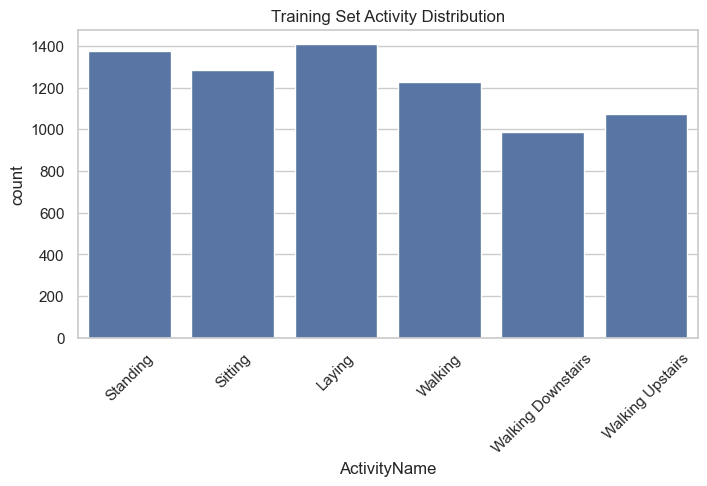

In [9]:
plt.figure(figsize=(8,4))
sns.countplot(x=y_train["ActivityName"])
plt.xticks(rotation=45)
plt.title("Training Set Activity Distribution")
plt.show()


In [10]:
features = pd.read_csv(
    "UCI HAR Dataset/features.txt",
    delim_whitespace=True,
    header=None,
    names=["Index", "Feature"]
)


C:\Users\suden\AppData\Local\Temp\ipykernel_14924\3615562520.py:1: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  features = pd.read_csv(


In [11]:
features.head()


,Index,Feature
0,1,tBodyAcc-mean()-X
1,2,tBodyAcc-mean()-Y
2,3,tBodyAcc-mean()-Z
3,4,tBodyAcc-std()-X
4,5,tBodyAcc-std()-Y


In [12]:
feature_name = "tBodyAcc-mean()-X"

feature_index = features[
    features["Feature"] == feature_name
]["Index"].values[0] - 1


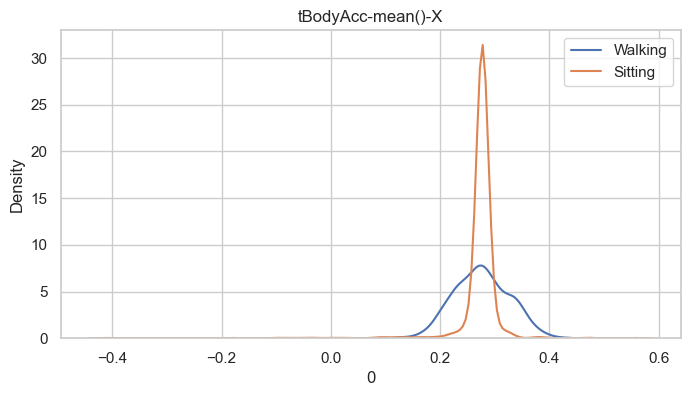

In [13]:
walking = X_train[y_train["ActivityName"] == "Walking"].iloc[:, feature_index]
sitting = X_train[y_train["ActivityName"] == "Sitting"].iloc[:, feature_index]

plt.figure(figsize=(8,4))
sns.kdeplot(walking, label="Walking")
sns.kdeplot(sitting, label="Sitting")
plt.title(feature_name)
plt.legend()
plt.show()


In [14]:
feature_name = "tBodyAcc-mean()-Z"

feature_index = features[
    features["Feature"] == feature_name
]["Index"].values[0] - 1


In [15]:
upstairs = X_train[
    y_train["ActivityName"] == "Walking Upstairs"
].iloc[:, feature_index]

downstairs = X_train[
    y_train["ActivityName"] == "Walking Downstairs"
].iloc[:, feature_index]


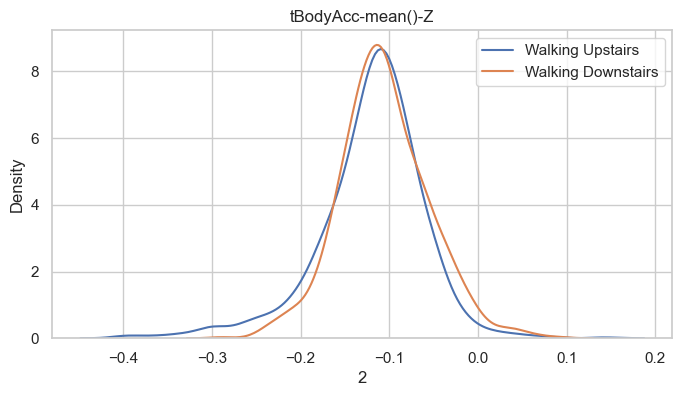

In [16]:
plt.figure(figsize=(8,4))
sns.kdeplot(upstairs, label="Walking Upstairs")
sns.kdeplot(downstairs, label="Walking Downstairs")
plt.title("tBodyAcc-mean()-Z")
plt.legend()
plt.show()


In [17]:
walking_freq = X_train[
    y_train["ActivityName"] == "Walking"
].iloc[:, feature_index]

sitting_freq = X_train[
    y_train["ActivityName"] == "Sitting"
].iloc[:, feature_index]


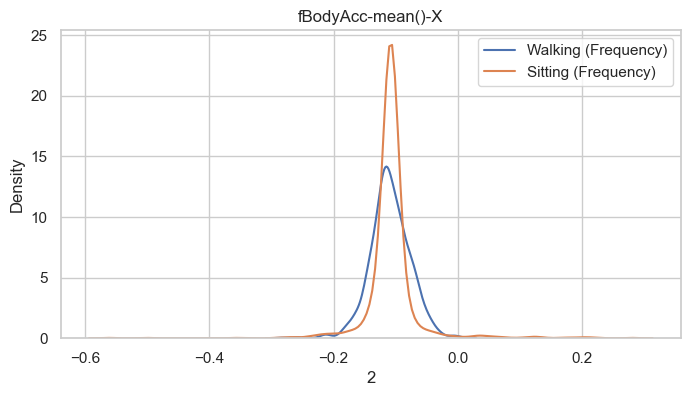

In [18]:
plt.figure(figsize=(8,4))
sns.kdeplot(walking_freq, label="Walking (Frequency)")
sns.kdeplot(sitting_freq, label="Sitting (Frequency)")
plt.title("fBodyAcc-mean()-X")
plt.legend()
plt.show()


In [19]:
X_test = pd.read_csv(
    "UCI HAR Dataset/test/X_test.txt",
    delim_whitespace=True,
    header=None
)

y_test = pd.read_csv(
    "UCI HAR Dataset/test/y_test.txt",
    header=None,
    names=["Activity"]
)

y_test["ActivityName"] = y_test["Activity"].map(activity_labels)


C:\Users\suden\AppData\Local\Temp\ipykernel_14924\3798434608.py:1: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  X_test = pd.read_csv(


In [20]:
X_test.shape, y_test.shape


((2947, 561), (2947, 2))

In [21]:
from sklearn.ensemble import RandomForestClassifier


In [22]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)


In [23]:
rf.fit(X_train, y_train["Activity"])


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [24]:
y_pred = rf.predict(X_test)


In [25]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test["Activity"], y_pred)
accuracy


0.9256871394638616

In [26]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test["Activity"],
    y_pred,
    target_names=activity_labels.values()
))


                    precision    recall  f1-score   support

           Walking       0.89      0.97      0.93       496
  Walking Upstairs       0.88      0.89      0.89       471
Walking Downstairs       0.97      0.86      0.91       420
           Sitting       0.91      0.90      0.90       491
          Standing       0.91      0.92      0.91       532
            Laying       1.00      1.00      1.00       537

          accuracy                           0.93      2947
         macro avg       0.93      0.92      0.92      2947
      weighted avg       0.93      0.93      0.93      2947



In [27]:
from sklearn.metrics import confusion_matrix


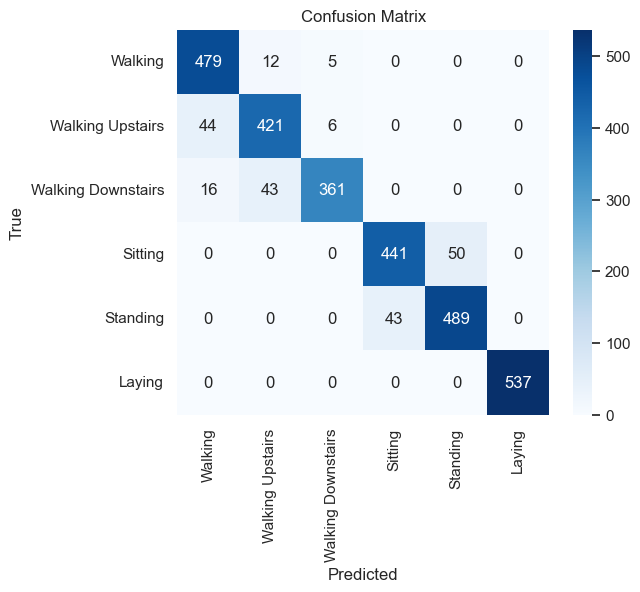

In [28]:
cm = confusion_matrix(y_test["Activity"], y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=activity_labels.values(),
    yticklabels=activity_labels.values()
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()


In [29]:
importances = rf.feature_importances_


In [30]:
indices = np.argsort(importances)[-10:]


In [31]:
top_features = features.iloc[indices]
top_features["Importance"] = importances[indices]

top_features


C:\Users\suden\AppData\Local\Temp\ipykernel_14924\3419323765.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top_features["Importance"] = importances[indices]


,Index,Feature,Importance
57,58,tGravityAcc-energy()-Y,0.015555
50,51,tGravityAcc-max()-Y,0.019443
53,54,tGravityAcc-min()-Y,0.021579
52,53,tGravityAcc-min()-X,0.022784
56,57,tGravityAcc-energy()-X,0.024571
559,560,"angle(Y,gravityMean)",0.025132
558,559,"angle(X,gravityMean)",0.029074
41,42,tGravityAcc-mean()-Y,0.029088
49,50,tGravityAcc-max()-X,0.030009
40,41,tGravityAcc-mean()-X,0.039640


In [32]:
from sklearn.preprocessing import StandardScaler


In [33]:
scaler = StandardScaler()


In [34]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [35]:
from sklearn.svm import SVC


In [36]:
svm = SVC(
    kernel="rbf",
    C=10,
    gamma="scale"
)


In [37]:
svm.fit(X_train_scaled, y_train["Activity"])


,C,10
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [38]:
y_pred_svm = svm.predict(X_test_scaled)


In [39]:
from sklearn.metrics import accuracy_score

svm_accuracy = accuracy_score(y_test["Activity"], y_pred_svm)
svm_accuracy


0.9548693586698337

In [40]:
from sklearn.metrics import confusion_matrix


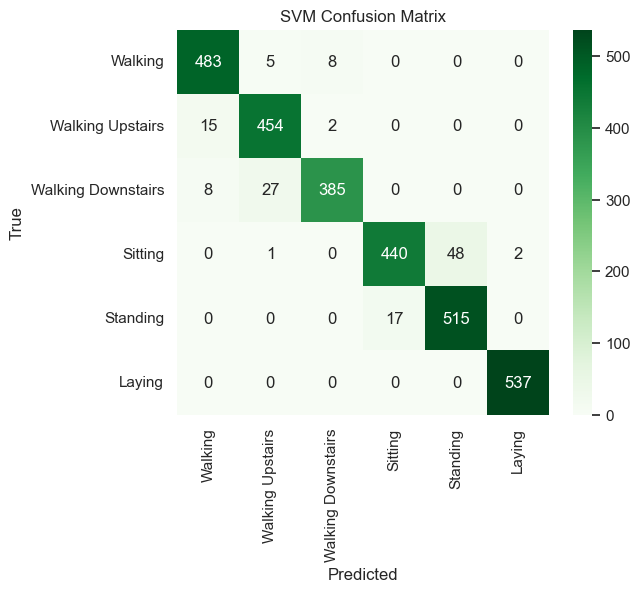

In [41]:
cm_svm = confusion_matrix(y_test["Activity"], y_pred_svm)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm_svm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=activity_labels.values(),
    yticklabels=activity_labels.values()
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("SVM Confusion Matrix")
plt.show()


In [42]:
print("Random Forest Accuracy:", accuracy)
print("SVM Accuracy:", svm_accuracy)


Random Forest Accuracy: 0.9256871394638616
SVM Accuracy: 0.9548693586698337
